In [168]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [87]:
coups_df = pd.read_csv('./data/cline_coups.csv')

### Clean data

In [88]:
realised_types = ['military',
       'dissident', 'rebel', 'palace', 'foreign', 'auto', 'resign', 'popular',
       'counter', 'other']

In [89]:
index_cols = ['coup_id', 'cowcode', 'year', 'realized']

In [90]:
coups_df = coups_df\
       .loc[:, index_cols + realised_types]\
       .melt(id_vars=index_cols, var_name='type')

In [92]:
coups_df = coups_df[coups_df['value']==1].drop('value', axis=1)

In [93]:
codes_df = pd.read_csv('./data/cow_codes.csv')

In [102]:
codes_df.drop_duplicates(inplace=True)

In [103]:
coups_df = coups_df\
    .merge(
    codes_df.iloc[:, :-1],
    left_on='cowcode',
    right_on='CCode',
    how='left'
    )\
    .drop(['CCode', 'cowcode'], axis=1)\
    .rename(columns = {'StateAbb': 'iso3'})\
    .loc[:, ['coup_id', 'iso3', 'year', 'type', 'realized']]

### EDA

* % of coups that are successful by country
* % of coups that are successful by type
* Most common types of coups
* Most common combinations of types of coups

#### Countries with most coups and rate of success

<Axes: xlabel='n', ylabel='success_prop'>

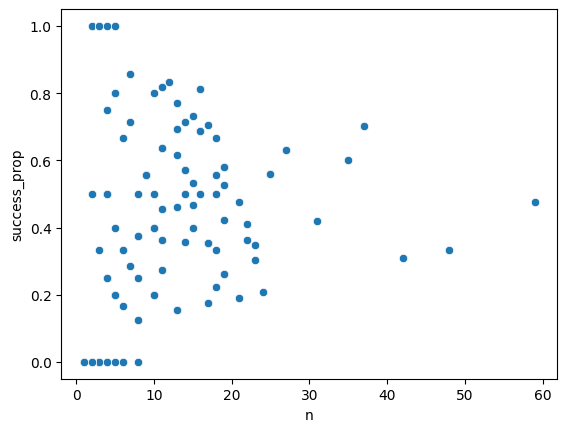

In [113]:
sns.scatterplot(
    data=coups_df\
    .groupby('iso3', as_index=False)\
    .agg(
        success_prop = ('realized', 'mean'),
        n = ('realized', 'count')
    ),
    x='n',
    y='success_prop'
)

In [114]:
coups_df\
    .groupby('iso3', as_index=False)\
    .agg(
        success_prop = ('realized', 'mean'),
        n = ('realized', 'count')
    )\
    .sort_values('n', ascending=False)\
    .head(10)

,iso3,success_prop,n
12,BOL,0.474576,59
113,SUD,0.333333,48
130,VEN,0.309524,42
53,HAI,0.702703,37
116,SYR,0.600000,35
4,ARG,0.419355,31
9,BFO,0.629630,27
119,THI,0.560000,25
58,IRQ,0.208333,24
20,CHA,0.304348,23


#### Most common types of coups

<Axes: xlabel='year'>

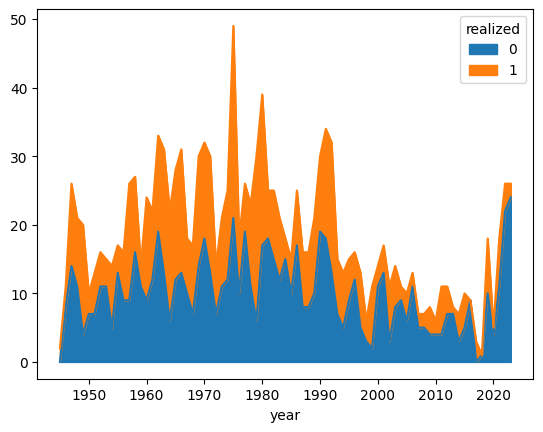

In [124]:
coups_df\
    .groupby(['year', 'realized'], as_index=False)\
    .size()\
    .pivot_table(index='year', columns='realized', values='size')\
    .plot.area()

<Axes: xlabel='type'>

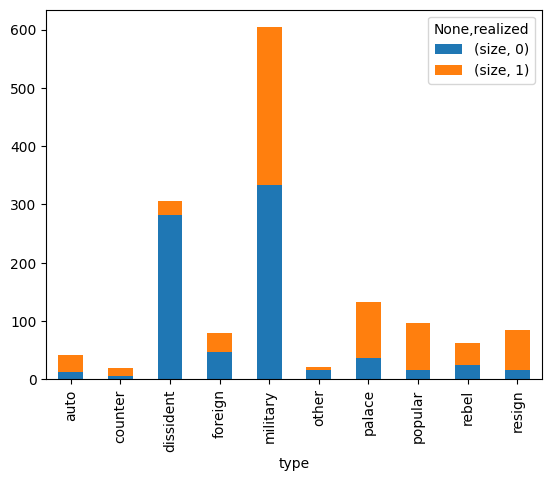

In [134]:
coups_df.\
    groupby(['type', 'realized'], as_index=False)\
    .size()\
    .pivot_table(index='type', columns='realized')\
    .plot.bar(stacked=True)

In [137]:
coups_df\
    .groupby('type', as_index=False)\
    ['realized'].mean()\
    .sort_values('realized', ascending=False)

,type,realized
7,popular,0.833333
9,resign,0.823529
6,palace,0.719697
0,auto,0.714286
1,counter,0.700000
8,rebel,0.619048
4,military,0.447020
3,foreign,0.412500
5,other,0.238095
2,dissident,0.081699


In [139]:
coup_types = coups_df['type'].unique().tolist()

In [159]:
combo_df = pd.DataFrame(columns=coup_types, index=coup_types).fillna(0)

/var/folders/24/ffx95prn69791671d3j9v39c0000gn/T/ipykernel_48594/258869023.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combo_df = pd.DataFrame(columns=coup_types, index=coup_types).fillna(0)


In [160]:
for coup in coups_df['coup_id'].unique():
    coup_type = coups_df.loc[coups_df['coup_id']==coup, 'type'].unique()
    for i in coup_type:
        for j in coup_type:
            combo_df.loc[combo_df.index == i, j] += 1

<Axes: >

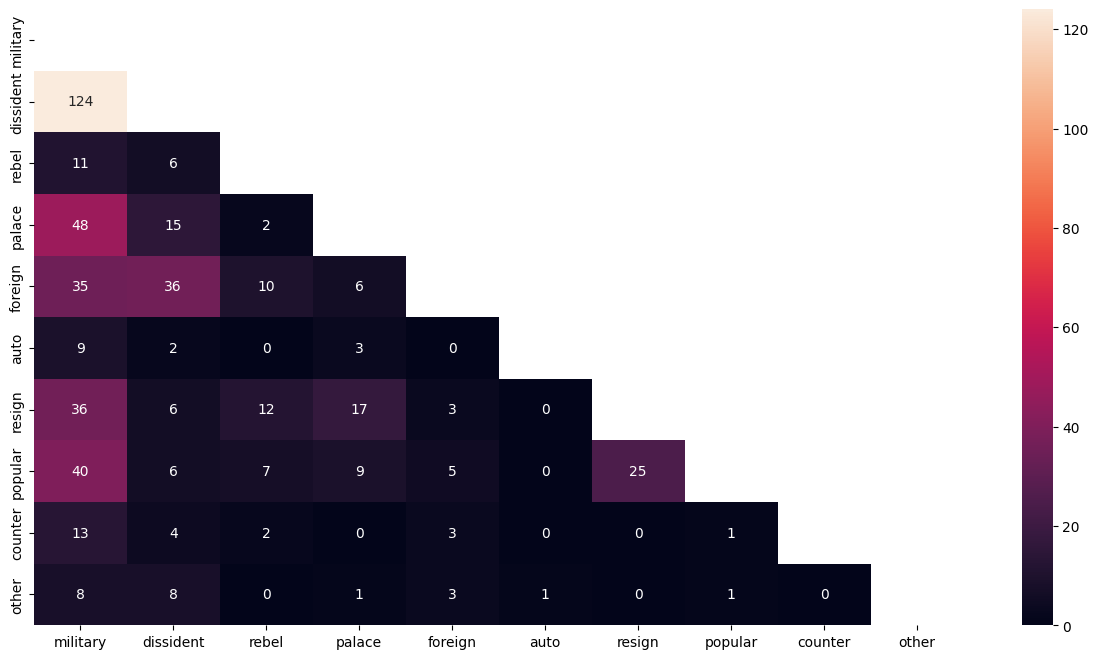

In [171]:
fig = plt.figure(figsize=(15, 8))

sns.heatmap(combo_df, annot=True, fmt='g', mask=np.triu(np.ones_like(combo_df)))

In [185]:
duration_cols = ['coup_id', 'iso3', 'year']

In [208]:
length_df = coups_df\
    .loc[(coups_df['iso3'].notna()) & (coups_df['realized']==1), duration_cols]\
    .drop_duplicates()\
    .sort_values(['iso3', 'year'])

In [209]:
length_df['duration'] = length_df.groupby('iso3')['year'].diff().shift(-1)

In [210]:
length_df = length_df\
    .dropna(subset=['duration'])\
    .merge(
        coups_df.drop('realized', axis=1),
        on=duration_cols,
        how='inner'
    )

<Axes: xlabel='type', ylabel='duration'>

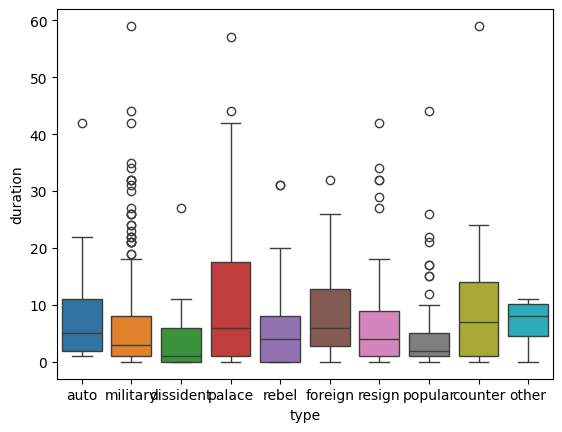

In [222]:
sns.boxplot(
    data=length_df,
    x='type',
    y='duration',
    hue='type',
)